# Vulnogram Version Analysis (Last 3 Months)

This notebook analyzes Vulnogram version usage across CNAs over the last 3 months to identify who is using outdated versions.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import re

## Load CVE Data

In [2]:
# Construct the base path relative to the current working directory
base_path = os.path.join(os.getcwd(), '..', '..', 'Data', 'CVE', 'cves')

data = []

# Traverse the directory tree
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.json'):
            file_path = os.path.join(root, file)
            with open(file_path, 'r') as f:
                cve_data = json.load(f)
                if isinstance(cve_data, dict):
                    cveId = cve_data.get('cveMetadata', {}).get('cveId')
                    shortName = cve_data.get('cveMetadata', {}).get('assignerShortName')
                    datePublished = cve_data.get('cveMetadata', {}).get('datePublished')
                    containers = cve_data.get('containers', {})
                    if isinstance(containers, dict):
                        cna = containers.get('cna', {})
                        if isinstance(cna, dict):
                            x_generator = cna.get('x_generator', {})
                            if isinstance(x_generator, dict):
                                x_generator = x_generator.get('engine')
                            else:
                                x_generator = None
                        else:
                            x_generator = None
                    else:
                        x_generator = None
                    data.append({
                        'cveId': cveId,
                        'shortName': shortName,
                        'x_generator': x_generator,
                        'datePublished': datePublished
                    })

cve_df = pd.DataFrame(data)
cve_df.rename(columns={
    'cveId': 'CVE',
    'shortName': 'CNA',
    'x_generator': 'Tool',
    'datePublished': 'Date'
}, inplace=True)

cve_df = cve_df.dropna(subset=['Date'])
print(f'Total CVE records loaded: {len(cve_df):,}')

Total CVE records loaded: 332,195


## Filter to Vulnogram Records

In [25]:
# Filter to only records that contain 'vulnogram' in the tool string
vulnogram_df = cve_df[cve_df['Tool'].str.contains('vulnogram', case=False, na=False)].copy()

# Extract the date part
vulnogram_df['Date'] = vulnogram_df['Date'].apply(
    lambda x: re.search(r'\d{4}-\d{2}-\d{2}', x).group(0) if pd.notna(x) and re.search(r'\d{4}-\d{2}-\d{2}', x) else None
)
vulnogram_df['Date'] = pd.to_datetime(vulnogram_df['Date'], errors='coerce')
vulnogram_df['Year'] = vulnogram_df['Date'].dt.year

# Extract the version number from the tool string
def extract_version(tool_str):
    match = re.search(r'(\d+\.\d+\.\d+[\w.-]*)', tool_str)
    return match.group(1) if match else 'unknown'

vulnogram_df['Version'] = vulnogram_df['Tool'].apply(extract_version)

# Filter to last 3 months
three_months_ago = pd.Timestamp.now() - pd.DateOffset(months=3)
vulnogram_df = vulnogram_df[vulnogram_df['Date'] >= three_months_ago]

print(f'Unique versions: {vulnogram_df["Version"].nunique()}')

print(f'Vulnogram CVE records (since {three_months_ago.strftime("%Y-%m-%d")}): {len(vulnogram_df):,}')
print(f'Unique raw tool strings: {vulnogram_df["Tool"].nunique()}')

Unique versions: 8
Vulnogram CVE records (since 2025-12-12): 2,647
Unique raw tool strings: 8


## Raw Vulnogram Tool Strings

In [26]:
# Show all unique raw tool strings and their counts
raw_versions = vulnogram_df['Tool'].value_counts().reset_index()
raw_versions.columns = ['Tool String', 'Count']
raw_versions['Percentage'] = (raw_versions['Count'] / raw_versions['Count'].sum() * 100).round(2)
raw_versions

,Tool String,Count,Percentage
0,Vulnogram 0.5.0,1670,63.09
1,Vulnogram 0.2.0,655,24.74
2,Vulnogram 0.1.0-dev,240,9.07
3,Vulnogram 1.0.0,59,2.23
4,Vulnogram 0.3.0,10,0.38
5,Vulnogram 1.0.0-beta,8,0.30
6,Vulnogram 0.4.0,3,0.11
7,Vulnogram,2,0.08


## Version Distribution

In [27]:
# The latest Vulnogram release is 1.0.0
LATEST_VERSION = '1.0.0'

version_counts = vulnogram_df['Version'].value_counts().reset_index()
version_counts.columns = ['Version', 'Count']
version_counts['Percentage'] = (version_counts['Count'] / version_counts['Count'].sum() * 100).round(2)
version_counts['Current'] = version_counts['Version'].apply(
    lambda v: 'Yes' if v.startswith(LATEST_VERSION) else 'No'
)
version_counts

,Version,Count,Percentage,Current
0,0.5.0,1670,63.09,No
1,0.2.0,655,24.74,No
2,0.1.0-dev,240,9.07,No
3,1.0.0,59,2.23,Yes
4,0.3.0,10,0.38,No
5,1.0.0-beta,8,0.30,Yes
6,0.4.0,3,0.11,No
7,unknown,2,0.08,No


## Vulnogram Version Usage by Month

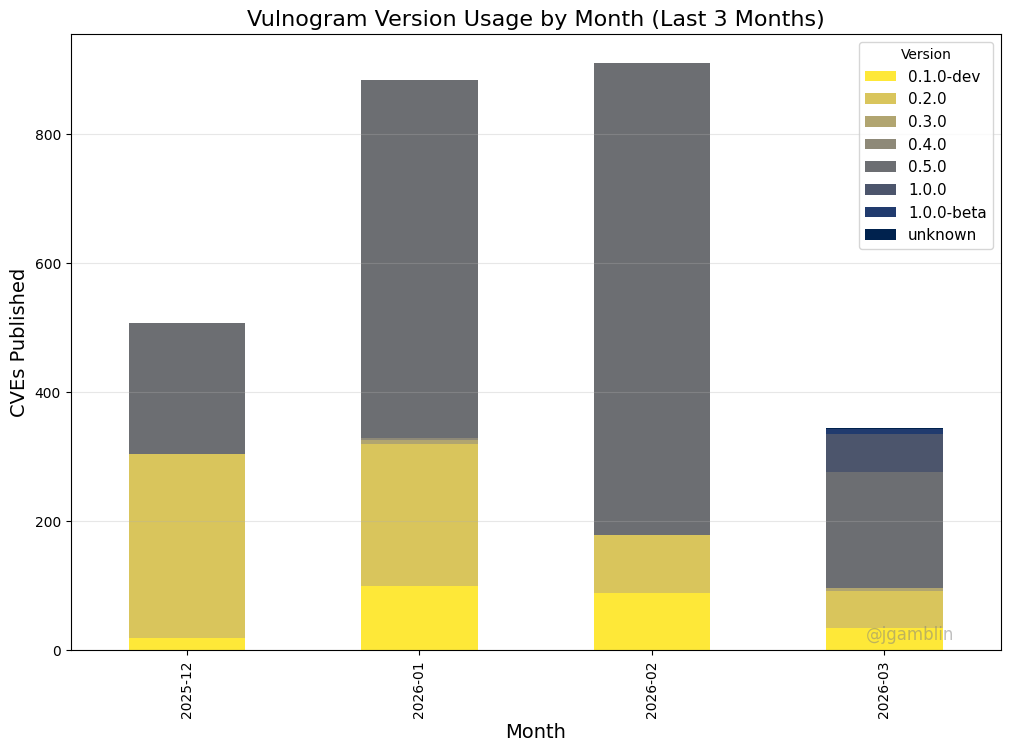

In [28]:
# Group by Month and Version
vulnogram_df['Month'] = vulnogram_df['Date'].dt.to_period('M')
grouped = vulnogram_df.groupby(['Month', 'Version']).size().reset_index(name='Count')
pivot = grouped.pivot(index='Month', columns='Version', values='Count').fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))
pivot.plot(kind='bar', stacked=True, colormap='cividis_r', ax=ax)

plt.title('Vulnogram Version Usage by Month (Last 3 Months)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('CVEs Published', fontsize=14)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Version', fontsize=11)

plt.text(0.95, 0.01, '@jgamblin', verticalalignment='bottom', horizontalalignment='right',
         transform=ax.transAxes, color='grey', fontsize=12, alpha=0.5)

plt.savefig('vulnogram_versions_by_month.png', dpi=300)
plt.savefig('vulnogram_versions_by_year.png', dpi=300)
plt.show()

## CNAs Using Old Versions of Vulnogram

CNAs whose most recent CVE filing used a Vulnogram version older than the current release.

In [29]:
# For each CNA, find the most recent CVE and what version they used
latest_per_cna = (
    vulnogram_df.sort_values('Date')
    .groupby('CNA')
    .last()
    .reset_index()[['CNA', 'CVE', 'Date', 'Version', 'Tool']]
)

# Filter out unknown versions and those on the latest version
old_version_cnas = (
    latest_per_cna[
        (latest_per_cna['Version'] != 'unknown') &
        (~latest_per_cna['Version'].str.startswith(LATEST_VERSION))
    ]
    .sort_values('Date', ascending=False)
    .reset_index(drop=True)
)

print(f'CNAs using Vulnogram: {len(latest_per_cna):,}')
print(f'CNAs on current version ({LATEST_VERSION}): {len(latest_per_cna[latest_per_cna["Version"].str.startswith(LATEST_VERSION)]):,}')
print(f'CNAs on old versions: {len(old_version_cnas):,}')

CNAs using Vulnogram: 208
CNAs on current version (1.0.0): 20
CNAs on old versions: 187


## Old Version Breakdown by Version

In [30]:
# Which old versions are CNAs stuck on?
old_version_summary = (
    old_version_cnas.groupby('Version')['CNA']
    .agg(['count', lambda x: ', '.join(sorted(x))])
    .reset_index()
)
old_version_summary.columns = ['Version', 'CNA Count', 'CNAs']
old_version_summary = old_version_summary.sort_values('CNA Count', ascending=False).reset_index(drop=True)
old_version_summary

,Version,CNA Count,CNAs
0,0.5.0,147,"2N, ABB, AHA, AMD, AMZN, ASRG, ASUS, ASUSTOR1,..."
1,0.2.0,26,"CERT-PL, CPANSec, Canon, DIVD, Deltaww, Docker..."
2,0.1.0-dev,13,"3DS, BLSOPS, CERTVDE, Esri, HW, Joomla, Mitsub..."
3,0.3.0,1,lenovo


## Export

In [31]:
# Export old version CNAs to CSV, sorted by version (old to new)
from packaging.version import Version

export_df = old_version_cnas.copy()
export_df['_sort_key'] = export_df['Version'].apply(lambda v: Version(v))
export_df = export_df.sort_values('_sort_key').drop(columns='_sort_key').reset_index(drop=True)
export_df.to_csv('vulnogram_old_versions.csv', index=False)
print(f'Exported {len(export_df)} CNAs on old Vulnogram versions to vulnogram_old_versions.csv (sorted old → new)')

Exported 187 CNAs on old Vulnogram versions to vulnogram_old_versions.csv (sorted old → new)
